In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## Raw vs Cleaned Dataset Check

Before continuing with the main EDA, we briefly compare the raw and cleaned datasets.  
This helps document how much the dataset changed after preprocessing and confirms that the EDA is based on the final cleaned version.

In [26]:
raw = pd.read_csv("data/compustat_raw.csv.csv")

print("Raw dataset shape:", raw.shape)
print("Cleaned dataset shape:", df.shape)

Raw dataset shape: (220729, 24)
Cleaned dataset shape: (95574, 14)


In [27]:
raw_unique_firms = raw["gvkey"].nunique()
clean_unique_firms = df["gvkey"].nunique()

print("Unique firms in raw data:", raw_unique_firms)
print("Unique firms in cleaned data:", clean_unique_firms)
print("Firms removed during cleaning:", raw_unique_firms - clean_unique_firms)

Unique firms in raw data: 25056
Unique firms in cleaned data: 11402
Firms removed during cleaning: 13654


In [28]:
print("Raw columns:")
print(raw.columns.tolist())

print("\nCleaned columns:")
print(df.columns.tolist())

Raw columns:
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'gvkey', 'datadate', 'conm', 'fyr', 'sic', 'act', 'at', 'ceq', 'dltt', 'lct', 'lt', 're', 'wcap', 'ebit', 'ebitda', 'ni', 'revt', 'xint', 'sich']

Cleaned columns:
['gvkey', 'conm', 'fyear', 'sich', 'leverage', 'roa', 'coverage', 'current_ratio', 'wcap_ratio', 'asset_turnover', 'retained_ratio', 'solvency', 'altman_z', 'distress']


In [29]:
raw_clean_summary = pd.DataFrame({
    "dataset": ["Raw data", "Cleaned data"],
    "rows": [raw.shape[0], df.shape[0]],
    "columns": [raw.shape[1], df.shape[1]],
    "unique_firms": [raw["gvkey"].nunique(), df["gvkey"].nunique()]
})

raw_clean_summary

,dataset,rows,columns,unique_firms
0,Raw data,220729,24,25056
1,Cleaned data,95574,14,11402


In [31]:
row_retention_rate = df.shape[0] / raw.shape[0] * 100
firm_retention_rate = df["gvkey"].nunique() / raw["gvkey"].nunique() * 100

print(f"Percentage of rows kept after cleaning: {row_retention_rate:.2f}%")
print(f"Percentage of firms kept after cleaning: {firm_retention_rate:.2f}%")

Percentage of rows kept after cleaning: 43.30%
Percentage of firms kept after cleaning: 45.51%


## Raw vs Cleaned Dataset Check

Before continuing with the main EDA, we briefly compare the raw and cleaned datasets.  
The raw dataset contains 220,729 firm-year observations and 25,056 unique firms. After preprocessing, the cleaned dataset contains 95,574 firm-year observations and 11,402 unique firms.

This means that 43.30% of the original firm-year observations and 45.51% of the original firms remain in the cleaned dataset. The reduction is expected because the cleaning process removes observations with missing or invalid values and keeps only the variables needed for financial ratio analysis and modeling.

The rest of the EDA uses the cleaned dataset, since it represents the final analysis-ready data.

##Clean Data EDA

In [3]:
df = pd.read_csv("data/compustat_clean.csv")
df.head()

,gvkey,conm,fyear,sich,leverage,roa,coverage,current_ratio,wcap_ratio,asset_turnover,retained_ratio,solvency,altman_z,distress
0,1004,AAR CORP,2000,5080.0,0.243519,0.047454,3.799710,3.120983,0.468896,1.382369,0.271291,0.541814,3.146915,0
1,1004,AAR CORP,2001,5080.0,0.256445,0.026403,2.940878,3.874697,0.513588,1.245637,0.290751,0.515267,3.048737,0
2,1004,AAR CORP,2002,5080.0,0.306532,-0.082989,1.374230,2.902063,0.402974,0.899355,0.196569,0.563172,2.145405,0
3,1004,AAR CORP,2003,5080.0,0.239809,-0.018074,1.573520,1.947253,0.280849,0.883074,0.180749,0.570377,1.942249,0
4,1004,AAR CORP,2004,5080.0,0.350583,0.004940,2.523566,3.292707,0.424286,0.919167,0.185938,0.574669,2.229527,0


In [4]:
df.shape

(95574, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95574 entries, 0 to 95573
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gvkey           95574 non-null  int64  
 1   conm            95574 non-null  object 
 2   fyear           95574 non-null  int64  
 3   sich            95574 non-null  float64
 4   leverage        95574 non-null  float64
 5   roa             95574 non-null  float64
 6   coverage        95574 non-null  float64
 7   current_ratio   95574 non-null  float64
 8   wcap_ratio      95574 non-null  float64
 9   asset_turnover  95574 non-null  float64
 10  retained_ratio  95574 non-null  float64
 11  solvency        95574 non-null  float64
 12  altman_z        95574 non-null  float64
 13  distress        95574 non-null  int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 10.2+ MB


## 1. Dataset Overview

This section provides a basic overview of the cleaned Compustat dataset used in the project.  
The goal is to understand the dataset size, variable types, time coverage, and the main financial variables before moving to deeper exploratory analysis.

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Number of rows: 95574
Number of columns: 14


,gvkey,conm,fyear,sich,leverage,roa,coverage,current_ratio,wcap_ratio,asset_turnover,retained_ratio,solvency,altman_z,distress
0,1004,AAR CORP,2000,5080.0,0.243519,0.047454,3.799710,3.120983,0.468896,1.382369,0.271291,0.541814,3.146915,0
1,1004,AAR CORP,2001,5080.0,0.256445,0.026403,2.940878,3.874697,0.513588,1.245637,0.290751,0.515267,3.048737,0
2,1004,AAR CORP,2002,5080.0,0.306532,-0.082989,1.374230,2.902063,0.402974,0.899355,0.196569,0.563172,2.145405,0
3,1004,AAR CORP,2003,5080.0,0.239809,-0.018074,1.573520,1.947253,0.280849,0.883074,0.180749,0.570377,1.942249,0
4,1004,AAR CORP,2004,5080.0,0.350583,0.004940,2.523566,3.292707,0.424286,0.919167,0.185938,0.574669,2.229527,0


### Column Types and Missing Values

Before starting the exploratory analysis, we check the data types and missing values.  
Since this is the cleaned version of the dataset, we expect no missing values in the final variables.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95574 entries, 0 to 95573
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gvkey           95574 non-null  int64  
 1   conm            95574 non-null  object 
 2   fyear           95574 non-null  int64  
 3   sich            95574 non-null  float64
 4   leverage        95574 non-null  float64
 5   roa             95574 non-null  float64
 6   coverage        95574 non-null  float64
 7   current_ratio   95574 non-null  float64
 8   wcap_ratio      95574 non-null  float64
 9   asset_turnover  95574 non-null  float64
 10  retained_ratio  95574 non-null  float64
 11  solvency        95574 non-null  float64
 12  altman_z        95574 non-null  float64
 13  distress        95574 non-null  int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 10.2+ MB


In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

gvkey             0
conm              0
fyear             0
sich              0
leverage          0
roa               0
coverage          0
current_ratio     0
wcap_ratio        0
asset_turnover    0
retained_ratio    0
solvency          0
altman_z          0
distress          0
dtype: int64

### Descriptive Statistics

We examine the summary statistics of the numerical variables.  
This helps us understand the scale, distribution, and possible extreme values in the financial ratios.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gvkey,95574.0,72818.169910,70177.097986,1004.000000,13962.000000,33133.000000,137642.000000,351590.000000
fyear,95574.0,2009.365832,6.182443,2000.000000,2004.000000,2009.000000,2015.000000,2020.000000
sich,95574.0,4389.730094,2071.004101,100.000000,2836.000000,3714.000000,5812.000000,9998.000000
leverage,95574.0,0.192436,0.243592,0.000000,0.000000,0.109740,0.299475,1.320035
roa,95574.0,-0.142664,0.508642,-3.469848,-0.129735,0.016023,0.067075,0.384659
coverage,95574.0,12.820963,43.858085,-50.000000,-2.667510,4.798976,20.406938,100.000000
current_ratio,95574.0,3.139937,4.082079,0.047566,1.192570,1.901174,3.305522,28.713784
wcap_ratio,95574.0,0.216819,0.368164,-1.910371,0.035863,0.199256,0.426126,0.926190
asset_turnover,95574.0,0.955333,0.817377,0.000000,0.388057,0.771590,1.301026,4.342106
retained_ratio,95574.0,-1.356704,4.323897,-31.917572,-0.894925,-0.002677,0.258562,0.913675


### Time Coverage

Since the dataset is firm-year level Compustat data, we check the fiscal year range and the number of observations by year.

In [10]:
print("First fiscal year:", df["fyear"].min())
print("Last fiscal year:", df["fyear"].max())
print("Number of unique fiscal years:", df["fyear"].nunique())

First fiscal year: 2000
Last fiscal year: 2020
Number of unique fiscal years: 21


In [11]:
df["fyear"].value_counts().sort_index()

fyear
2000    5962
2001    5585
2002    5373
2003    5183
2004    5037
2005    4881
2006    4656
2007    4507
2008    4395
2009    4238
2010    4166
2011    4209
2012    4346
2013    4259
2014    4130
2015    4024
2016    3988
2017    3991
2018    4037
2019    4209
2020    4398
Name: count, dtype: int64

### Firm Coverage

We check how many unique firms are included in the dataset.

In [12]:
print("Number of unique firms:", df["gvkey"].nunique())
print("Number of unique company names:", df["conm"].nunique())

Number of unique firms: 11402
Number of unique company names: 11401


In [13]:
name_gvkey_counts = df.groupby("conm")["gvkey"].nunique().sort_values(ascending=False)

name_gvkey_counts.head(10)

conm
WARNER CHILCOTT PLC          2
OSG AMERICA LP               1
ORION SA                     1
ORLA MINING LTD              1
ORLEANS HOMEBUILDERS INC     1
ORMET CORP                   1
OROSUR MINING INC            1
ORPHAN MEDICAL INC           1
ORSU METALS CORP             1
ORSUS XELENT TECHNOLOGIES    1
Name: gvkey, dtype: int64

The number of unique firm identifiers is slightly higher than the number of unique company names. This suggests that at least one company name is associated with more than one Compustat firm identifier, which can occur due to corporate restructuring, name reuse, or changes in Compustat entity definitions.

## 2. Target Variable: Financial Distress

The target variable in this project is `distress`.  
It indicates whether a firm-year observation is classified as financially distressed.

Before building supervised learning models, we first examine how common financial distress is in the dataset.

In [15]:
df["distress"].value_counts()

distress
0    56349
1    39225
Name: count, dtype: int64

In [16]:
df["distress"].value_counts(normalize=True) * 100

distress
0    58.958503
1    41.041497
Name: proportion, dtype: float64

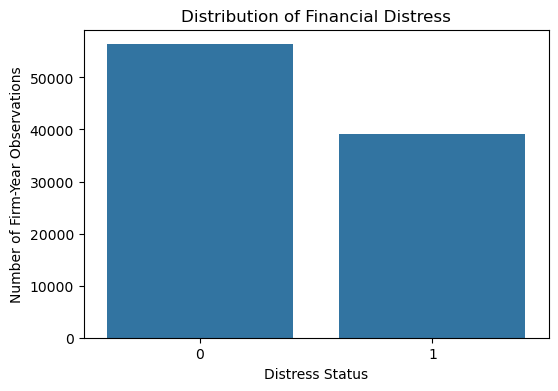

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="distress")

plt.title("Distribution of Financial Distress")
plt.xlabel("Distress Status")
plt.ylabel("Number of Firm-Year Observations")
plt.show()

In [18]:
distress_counts = df["distress"].value_counts()
distress_rates = df["distress"].value_counts(normalize=True) * 100

distress_summary = pd.DataFrame({
    "count": distress_counts,
    "percentage": distress_rates.round(2)
})

distress_summary

,count,percentage
distress,,
0,56349,58.96
1,39225,41.04


The distress label is defined at the firm-year level, not at the firm level. Therefore, the same firm can be classified as non-distressed in one year and distressed in another year. This structure is appropriate for our panel dataset because financial distress is a time-varying condition.

The distribution shows that 41.04% of firm-year observations are labeled as distressed, while 58.96% are non-distressed. This means that the target variable is not extremely imbalanced. However, the distress rate is relatively high compared to actual bankruptcy rates, which is expected because our label captures a technical financial distress proxy rather than legal bankruptcy.

## 3. Main Explanatory Variable: Leverage

Leverage is the main financial variable in our research question.  
We examine its distribution to understand how debt levels vary across firm-year observations and whether there are extreme values.

In [32]:
df["leverage"].describe()

count    95574.000000
mean         0.192436
std          0.243592
min          0.000000
25%          0.000000
50%          0.109740
75%          0.299475
max          1.320035
Name: leverage, dtype: float64

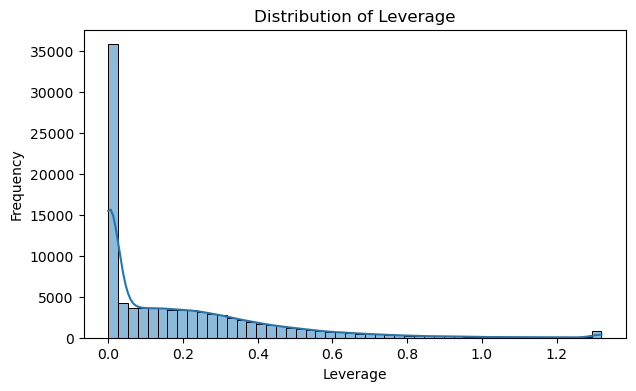

In [33]:
plt.figure(figsize=(7, 4))

sns.histplot(df["leverage"], bins=50, kde=True)

plt.title("Distribution of Leverage")
plt.xlabel("Leverage")
plt.ylabel("Frequency")
plt.show()

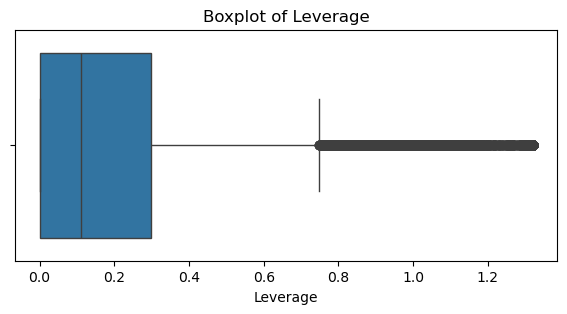

In [34]:
plt.figure(figsize=(7, 3))

sns.boxplot(x=df["leverage"])

plt.title("Boxplot of Leverage")
plt.xlabel("Leverage")
plt.show()

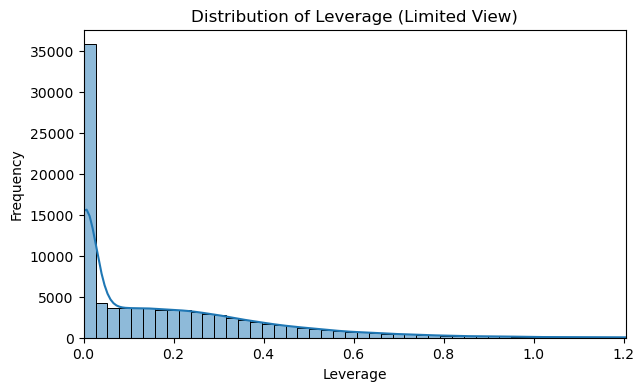

In [35]:
plt.figure(figsize=(7, 4))

sns.histplot(df["leverage"], bins=50, kde=True)

plt.title("Distribution of Leverage (Limited View)")
plt.xlabel("Leverage")
plt.ylabel("Frequency")
plt.xlim(df["leverage"].quantile(0.01), df["leverage"].quantile(0.99))
plt.show()

Leverage measures the extent to which a firm is financed by debt. In this project, leverage is the main explanatory variable because our research question asks whether higher debt levels are associated with financial distress.

The distribution of leverage is right-skewed. Most firm-year observations have relatively low leverage, while a smaller number of observations have much higher leverage values. The median leverage is 0.11, while the mean is 0.19, which suggests that high-leverage observations pull the average upward.

The boxplot also shows several high-leverage observations. These values may represent firms with unusually high debt levels, which are important for our project because highly leveraged firms may be more exposed to financial distress.